In [4]:
import equinox as eqx
import numpy as np
import jax 
import jax.numpy as jnp

class SNICAREmulator(eqx.Module):
    layers: list
 
    def __init__(self, in_dim, key):
        keys = jax.random.split(key, 4)
        self.layers = [
            eqx.nn.Linear(in_dim, 128, key=keys[0]), eqx.nn.LayerNorm((128,)),
            eqx.nn.Linear(128,    128, key=keys[1]), eqx.nn.LayerNorm((128,)),
            eqx.nn.Linear(128,     64, key=keys[2]), eqx.nn.LayerNorm((64,)),
            eqx.nn.Linear(64,       1, key=keys[3]),
        ]
 
    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = jax.nn.gelu(layer(x)) if isinstance(layer, eqx.nn.Linear) else layer(x)
        return jax.nn.sigmoid(self.layers[-1](x)).squeeze()
    
# load once at startup
model = eqx.tree_deserialise_leaves('snicar_emulator.eqx', SNICAREmulator(25, jax.random.PRNGKey(0)))
norm  = np.load('snicar_norm.npz')
mu, sigma = jnp.array(norm['mu']), jnp.array(norm['sigma'])

# # inside your timestep
# X = jnp.concatenate([...], axis=1)  # (N_POINTS, 25)
# albedo = jax.vmap(model)((X - mu) / sigma)  # (N_POINTS,)

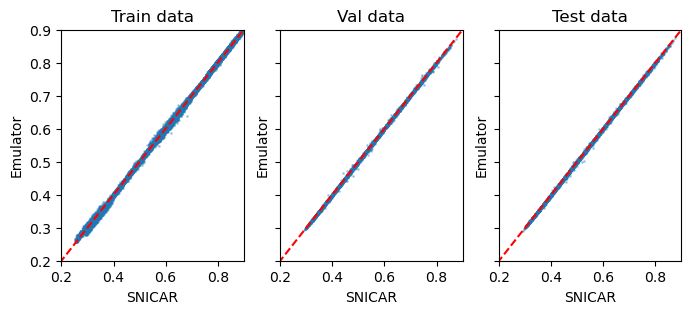

In [10]:
import numpy as np 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3))

for split, ax in zip(['train','val','test'], axes):
    data  = np.load(f'snicar_data/snicar_{split}.npz')
    X, y = jnp.array(data['X']), jnp.array(data['y'])
    y_pred = jax.vmap(model)((X - mu) / sigma)

    ax.scatter(y, y_pred, s=1, alpha=0.3)
    ax.plot([0,1],[0,1],'r--')
    ax.set_xlabel('SNICAR')
    ax.set_ylabel('Emulator')
    ax.set_xlim(0.2, 0.9)
    ax.set_ylim(0.2, 0.9)
    ax.set_title(split.capitalize() + ' data')
plt.show()